Brian Slonim

# Feline Age Prediction

Attributions:
* The dataset used comes from "A deep learning pipeline for age prediction from vocalisations of the domestic feline" by Van Toor et al., (2025). ([link](https://doi.org/10.1038/s41598-025-17986-z))
* The creation of small parts of this notebook were aided by the Gemini widget in Google CoLab, primarily for the usage of library functions with which I was unfamiliar. All logic and analysis is my own.

## Download Dataset

In [ ]:
import os
import shutil

In [ ]:
def download_dataset(repo_url: str, dir_path_in_repo: str, output_dir_name: str):
    # Extract the repo name
    repo_name = repo_url.split('/')[-1].replace('.git', '')

    # Clone the entire repo
    print(f"Cloning repository: {repo_url}...")
    !git clone --depth 1 {repo_url} {repo_name}

    # Construct full path to desired directory
    source_path = os.path.join(repo_name, dir_path_in_repo)

    # Check if source path exists before copying
    if os.path.exists(source_path):
        # Remove any existing output directory to avoid errors from previous runs
        if os.path.exists(output_dir_name):
            shutil.rmtree(output_dir_name)
            print(f"Removed existing directory './{output_dir_name}'")

        # Copy the desired directory to the current working directory
        shutil.copytree(source_path, output_dir_name)
        print(f"Successfully copied '{dir_path_in_repo}' to './{output_dir_name}'")

        # Clean up the cloned repository
        shutil.rmtree(repo_name)
        print(f"Cleaned up cloned repository '{repo_name}'.")
    else:
        print(f"Error: Directory '{dir_path_in_repo}' not found in the cloned repository at '{source_path}'.")


In [ ]:
DATASET_DIR = "feline_age_prediction_dataset"

In [ ]:
download_dataset(
    "https://github.com/aster-droide/feline-age-prediction.git",
    os.path.join("dataset", "embeddings"),
    DATASET_DIR
)
print("\n--- Verify downloaded directories ---")
!ls -F

Cloning repository: https://github.com/aster-droide/feline-age-prediction.git...
Cloning into 'feline-age-prediction'...
remote: Enumerating objects: 3207, done.
remote: Counting objects: 100% (3207/3207), done.
remote: Compressing objects: 100% (2411/2411), done.
remote: Total 3207 (delta 1588), reused 2404 (delta 796), pack-reused 0 (from 0)
Receiving objects: 100% (3207/3207), 364.56 MiB | 12.97 MiB/s, done.
Resolving deltas: 100% (1588/1588), done.
Updating files: 100% (3199/3199), done.
Successfully copied 'dataset/embeddings' to './feline_age_prediction_dataset'
Cleaned up cloned repository 'feline-age-prediction'.

--- Verify downloaded directories ---
feline_age_prediction_dataset/	sample_data/


## Data Pre-processing

### Read Data

In [ ]:
RANDOM_STATE = 42

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
def read_embeddings_csv(file_path: str) -> pd.DataFrame:
    df = pd.read_csv(file_path)
    return df

In [ ]:
embeddings_path = os.path.join(DATASET_DIR, 'yamnet_looped_embeddings.csv')

orig_embeddings = read_embeddings_csv(embeddings_path)
orig_embeddings.columns

Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9',
       ...
       '1017', '1018', '1019', '1020', '1021', '1022', '1023', 'gender',
       'target', 'cat_id'],
      dtype='object', length=1027)

### Pre-processing Steps

#### 0. Isolate Target Variable

In [ ]:
AGE_GROUP_CATEGORIES = ['Kitten', 'Adult', 'Senior']

In [ ]:
NUM_CLASSES = len(AGE_GROUP_CATEGORIES)

In [ ]:
def age_to_age_group(age: float) -> str:
    if age <= 1:
        return 0
    elif age <= 10:
        return 1
    else:
        return 2

In [ ]:
def fix_embeddings_labels(embeddings: pd.DataFrame, label_col: str) -> pd.DataFrame:
  new_df = embeddings.rename(columns={'target': 'age'})
  new_df['age_group'] = new_df['age'].apply(age_to_age_group)

  # original features are numbered 0-1023
  new_df = new_df.drop(columns=[col for col in new_df.columns if col != label_col and not col.isnumeric()])

  # remove any rows with missing values
  bad = new_df.isna().any(axis=1)
  new_df = new_df[~bad]

  return new_df

In [ ]:
fixed_embeddings = fix_embeddings_labels(orig_embeddings, 'age_group')
fixed_embeddings.columns

Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9',
       ...
       '1015', '1016', '1017', '1018', '1019', '1020', '1021', '1022', '1023',
       'age_group'],
      dtype='object', length=1025)

#### 1. Train/Val/Test Split

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
def split_embeddings(all_embeddings: pd.DataFrame, label_col: str,
                     val_size: float = 0.1, test_size: float = 0.1) -> tuple[pd.DataFrame]:
  features = all_embeddings.drop(columns=label_col)
  targets = all_embeddings[label_col]

  # First split: training set and a temp set (val + test)
  train_features, temp_features, train_targets, temp_targets = train_test_split(
      features, targets, test_size=(val_size + test_size), random_state=RANDOM_STATE, shuffle=True,
      stratify=targets
  )

  # Adjust val and test sizes for second split
  if (val_size + test_size) > 0:
      new_test_size = test_size / (val_size + test_size)
  else:
      new_test_size = 0

  # Second split: val set and test set from temp set
  val_features, test_features, val_targets, test_targets = train_test_split(
      temp_features, temp_targets, test_size=new_test_size, random_state=RANDOM_STATE, shuffle=True,
      stratify=temp_targets
  )

  return train_features, val_features, test_features, train_targets, val_targets, test_targets

In [ ]:
(train_features, val_features,
 test_features, train_targets,
 val_targets, test_targets) = split_embeddings(fixed_embeddings, 'age_group', 0.1, 0.1)

In [ ]:
print(f'Train features: {train_features.shape}')
print(f'Val features: {val_features.shape}')
print(f'Test features: {test_features.shape}')
print(f'Train targets: {train_targets.shape}')
print(f'Val targets: {val_targets.shape}')
print(f'Test targets: {test_targets.shape}')

Train features: (774, 1024)
Val features: (97, 1024)
Test features: (97, 1024)
Train targets: (774,)
Val targets: (97,)
Test targets: (97,)


#### 2. Standardization

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
def scale_embeddings(train_features: pd.DataFrame,
                   val_features: pd.DataFrame | None,
                   test_features: pd.DataFrame) -> tuple[pd.DataFrame]:
    scaler = StandardScaler()
    scaler.fit_transform(train_features)
    if val_features is not None:
        scaler.transform(val_features)
    scaler.transform(test_features)

    return train_features, val_features, test_features

In [ ]:
(train_features_scaled,
 val_features_scaled,
 test_features_scaled) = scale_embeddings(train_features, val_features, test_features)

In [ ]:
print(f'Train features scaled: {train_features_scaled.shape}')
print(f'Val features PCA: {val_features_scaled.shape}')
print(f'Test features PCA: {test_features_scaled.shape}')

Train features scaled: (774, 1024)
Val features PCA: (97, 1024)
Test features PCA: (97, 1024)


#### 3. Dimensionality Reduction

In [ ]:
from sklearn.decomposition import PCA

In [ ]:
def pca_embeddings(train_features: pd.DataFrame,
                   val_features: pd.DataFrame | None,
                   test_features: pd.DataFrame,
                   n_components: int) -> tuple[pd.DataFrame]:
    if val_features is not None and not train_features.columns.equals(val_features.columns):
        raise ValueError("Train and val features columns mismatch")
    if not train_features.columns.equals(test_features.columns):
        raise ValueError("Train and test features columns mismatch")

    pca = PCA(n_components=n_components, random_state=RANDOM_STATE)

    # Use only numeric columns for PCA
    numeric_cols = train_features.select_dtypes(include=[np.number]).columns
    if len(numeric_cols) == 0:
        raise ValueError("No numeric columns available for PCA")

    # Fit PCA to train features, then transform all features
    train_features_reduced = pca.fit_transform(train_features[numeric_cols].values)
    if val_features is not None:
        val_features_reduced = pca.transform(val_features[numeric_cols].values)
    test_features_reduced = pca.transform(test_features[numeric_cols].values)

    # Put reduced vectors back into DataFrames
    train_reduced_df = pd.DataFrame(train_features_reduced, columns=[f'pca_{i}' for i in range(train_features_reduced.shape[1])],
                              index=train_features.index)
    val_reduced_df = None
    if val_features is not None:
        val_reduced_df = pd.DataFrame(val_features_reduced, columns=[f'pca_{i}' for i in range(val_features_reduced.shape[1])],
                              index=val_features.index)
    test_reduced_df = pd.DataFrame(test_features_reduced, columns=[f'pca_{i}' for i in range(test_features_reduced.shape[1])],
                              index=test_features.index)
    return train_reduced_df, val_reduced_df, test_reduced_df

In [ ]:
PCA_NUM_COMPONENTS = 32

In [ ]:
(train_features_reduced,
 val_features_reduced,
 test_features_reduced) = pca_embeddings(train_features_scaled, val_features_scaled, test_features_scaled, PCA_NUM_COMPONENTS)

In [ ]:
print(f'Train features PCA: {train_features_reduced.shape}')
print(f'Val features PCA: {val_features_reduced.shape}')
print(f'Test features PCA: {test_features_reduced.shape}')

Train features PCA: (774, 32)
Val features PCA: (97, 32)
Test features PCA: (97, 32)


From now on, **only** the following DataFrames should be used for the data:

- `train_features_reduced` and `train_targets`
- `val_features_reduced` and `val_targets`
- `test_features_reduced` and `test_targets`

## Create torch Tensors/Datasets

In [ ]:
import torch

In [ ]:
torch.manual_seed(RANDOM_STATE)

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

In [ ]:
train_features_tensor = torch.tensor(train_features_reduced.values, dtype=torch.float32)
train_targets_tensor = torch.tensor(train_targets.values, dtype=torch.long)
val_features_tensor = torch.tensor(val_features_reduced.values, dtype=torch.float32)
val_targets_tensor = torch.tensor(val_targets.values, dtype=torch.long)
test_features_tensor = torch.tensor(test_features_reduced.values, dtype=torch.float32)
test_targets_tensor = torch.tensor(test_targets.values, dtype=torch.long)

In [ ]:
print(f'Train features: {train_features_tensor.shape}')
print(f'Val features: {val_features_tensor.shape}')
print(f'Test features: {test_features_tensor.shape}')
print(f'Train targets: {train_targets_tensor.shape}')
print(f'Val targets: {val_targets_tensor.shape}')
print(f'Test targets: {test_targets_tensor.shape}')

Train features: torch.Size([774, 32])
Val features: torch.Size([97, 32])
Test features: torch.Size([97, 32])
Train targets: torch.Size([774])
Val targets: torch.Size([97])
Test targets: torch.Size([97])


In [ ]:
train_dataset = TensorDataset(train_features_tensor, train_targets_tensor)
val_dataset = TensorDataset(val_features_tensor, val_targets_tensor)
test_dataset = TensorDataset(test_features_tensor, test_targets_tensor)

In [ ]:
BATCH_SIZE = 32

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
print(f"Train DataLoader: {len(train_loader)} batches of size {train_loader.batch_size}")
print(f"Val DataLoader: {len(val_loader)} batches of size {val_loader.batch_size}")
print(f"Test DataLoader: {len(test_loader)} batches of size {test_loader.batch_size}")

Train DataLoader: 25 batches of size 32
Val DataLoader: 4 batches of size 32
Test DataLoader: 4 batches of size 32


## Model Creation

Train a neural network on the dataset without any regularization or other special techniques to get a baseline train and test error.  Then see how much you can improve the network's test error through techniques learned in class like regularization, different optimizers, batch normalization, etc.

### Util Functions/Constants

In [ ]:
from torch import nn

In [ ]:
def eval_model(model_to_eval: nn.Module, loader: DataLoader) -> float:
  model_to_eval.eval()
  total_correct = 0
  total_samples = 0

  with torch.no_grad(): # don't need gradients for inference
    for features, targets in loader:
      z = model_to_eval(features)
      predicted = torch.argmax(z, dim=1) # get index of highest in each row

      total_correct += (predicted == targets).sum().item()
      total_samples += targets.size(0)

  acc = total_correct / total_samples
  return acc

In [ ]:
LOSS_FN = nn.CrossEntropyLoss()

In [ ]:
from torch import optim

In [ ]:
def train_model(model_to_train: nn.Module, optimizer: optim.Optimizer,
                epochs: int, verbose: bool = False) -> dict[str, list[float]]:
  acc_per_epoch = {'train': [], 'val': []}
  acc_per_epoch['train'].append(eval_model(model_to_train, train_loader))
  acc_per_epoch['val'].append(eval_model(model_to_train, test_loader))

  print('Begin training model')

  for epoch in range(epochs):
    model_to_train.train()
    if verbose or epoch % 10 == 9:
      print(f'Epoch {epoch + 1}/{epochs}')

    for i, (features, targets) in enumerate(train_loader):
      optimizer.zero_grad() # zero out gradients before each BW pass
      z = model_to_train(features) # compute z values using batched features
      loss = LOSS_FN(z,targets) # compute loss using batched targets

      if verbose and i % 200 == 0:
        print(f'Batch {i}: loss={loss.item()}')

      loss.backward() # compute gradients
      optimizer.step() # apply gradients

    acc_per_epoch['train'].append(eval_model(model_to_train, train_loader))
    acc_per_epoch['val'].append(eval_model(model_to_train, test_loader))

  print('End training model')

  return acc_per_epoch

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
def plot_acc_per_epoch(accuracies: dict[str, list[float]]) -> None:
    plt.figure(figsize=(12, 8))
    plt.plot(accuracies['train'], label=f'Train Accuracy')
    plt.plot(accuracies['val'], label=f'Validation Accuracy', linestyle='--')

    plt.title('Train and Validation Accuracy Across Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
LR = 1e-2

### Baseline Model

In [ ]:
baseline_model = nn.Sequential(
    nn.Linear(PCA_NUM_COMPONENTS, 100),
    nn.SiLU(),
    nn.Linear(100, 100),
    nn.SiLU(),
    nn.Linear(100, NUM_CLASSES)
)

In [ ]:
baseline_opt = optim.SGD(baseline_model.parameters(), LR)

In [ ]:
acc_per_epoch = train_model(baseline_model, baseline_opt, 100)

Begin training model
Epoch 10/100
Epoch 20/100
Epoch 30/100
Epoch 40/100
Epoch 50/100
Epoch 60/100
Epoch 70/100
Epoch 80/100
Epoch 90/100
Epoch 100/100
End training model


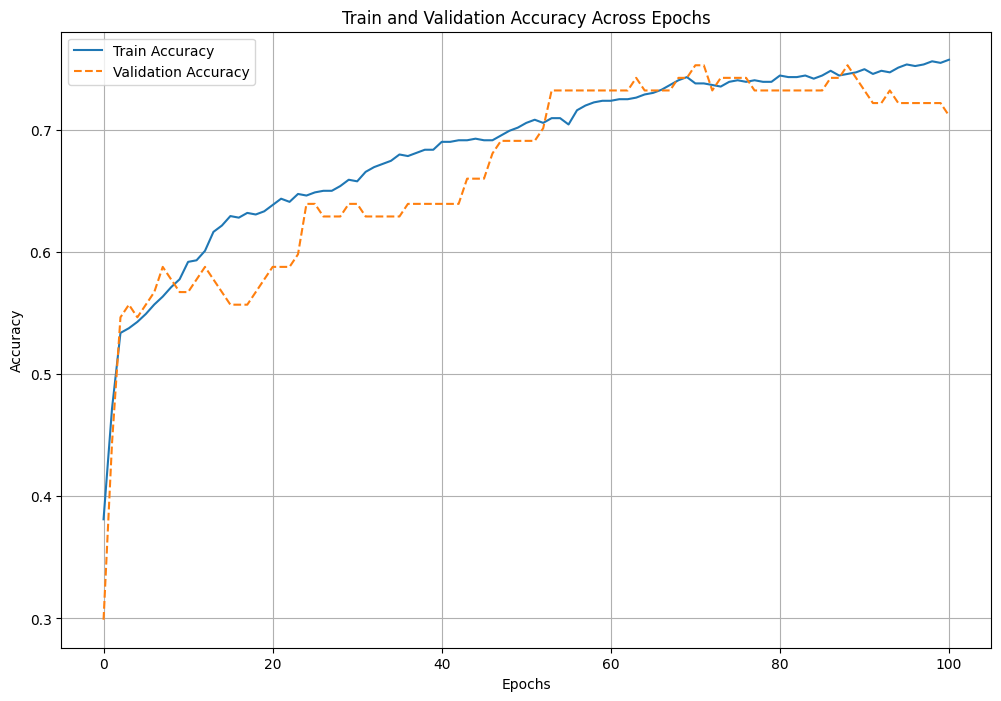

In [ ]:
plot_acc_per_epoch(acc_per_epoch)

### Bigger Model with BatchNorm

In [ ]:
bigger_model = nn.Sequential(
    nn.Linear(PCA_NUM_COMPONENTS, 100),
    nn.BatchNorm1d(100),
    nn.SiLU(),
    nn.Linear(100, 150),
    nn.BatchNorm1d(150),
    nn.SiLU(),
    nn.Linear(150, 200),
    nn.BatchNorm1d(200),
    nn.SiLU(),
    nn.Linear(200, 200),
    nn.BatchNorm1d(200),
    nn.SiLU(),
    nn.Linear(200, 150),
    nn.BatchNorm1d(150),
    nn.SiLU(),
    nn.Linear(150, 100),
    nn.BatchNorm1d(100),
    nn.SiLU(),
    nn.Linear(100, NUM_CLASSES)
)

In [ ]:
bigger_opt = optim.SGD(bigger_model.parameters(), LR)

In [ ]:
acc_per_epoch = train_model(bigger_model, bigger_opt, 100)

Begin training model
Epoch 10/100
Epoch 20/100
Epoch 30/100
Epoch 40/100
Epoch 50/100
Epoch 60/100
Epoch 70/100
Epoch 80/100
Epoch 90/100
Epoch 100/100
End training model


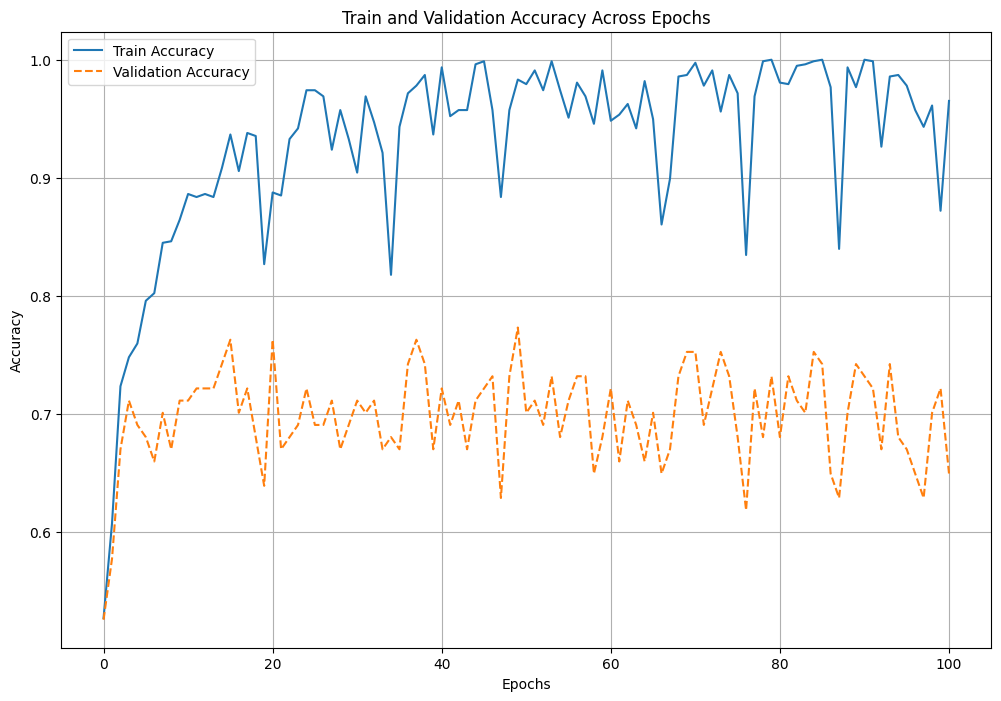

In [ ]:
plot_acc_per_epoch(acc_per_epoch)

### Bigger Model with BatchNorm and L2 Regularization

In [ ]:
bigger_model_2 = nn.Sequential(
    nn.Linear(PCA_NUM_COMPONENTS, 100),
    nn.BatchNorm1d(100),
    nn.SiLU(),
    nn.Linear(100, 150),
    nn.BatchNorm1d(150),
    nn.SiLU(),
    nn.Linear(150, 200),
    nn.BatchNorm1d(200),
    nn.SiLU(),
    nn.Linear(200, 200),
    nn.BatchNorm1d(200),
    nn.SiLU(),
    nn.Linear(200, 150),
    nn.BatchNorm1d(150),
    nn.SiLU(),
    nn.Linear(150, 100),
    nn.BatchNorm1d(100),
    nn.SiLU(),
    nn.Linear(100, NUM_CLASSES)
)

In [ ]:
bigger_opt_2 = optim.SGD(bigger_model_2.parameters(), LR, weight_decay=0.001)

In [ ]:
acc_per_epoch = train_model(bigger_model_2, bigger_opt_2, 100)

Begin training model
Epoch 10/100
Epoch 20/100
Epoch 30/100
Epoch 40/100
Epoch 50/100
Epoch 60/100
Epoch 70/100
Epoch 80/100
Epoch 90/100
Epoch 100/100
End training model


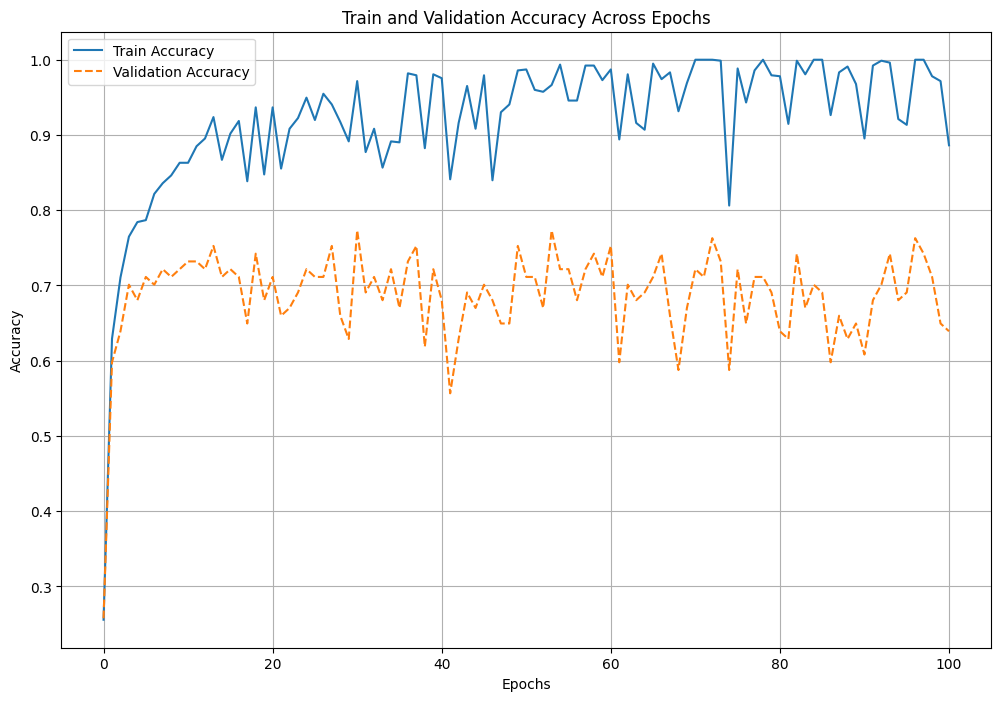

In [ ]:
plot_acc_per_epoch(acc_per_epoch)

### Bigger Model with Batch Normalization and Adam Optimizer

In [ ]:
bigger_model_3 = nn.Sequential(
    nn.Linear(PCA_NUM_COMPONENTS, 100),
    nn.BatchNorm1d(100),
    nn.SiLU(),
    nn.Linear(100, 150),
    nn.BatchNorm1d(150),
    nn.SiLU(),
    nn.Linear(150, 200),
    nn.BatchNorm1d(200),
    nn.SiLU(),
    nn.Linear(200, 200),
    nn.BatchNorm1d(200),
    nn.SiLU(),
    nn.Linear(200, 150),
    nn.BatchNorm1d(150),
    nn.SiLU(),
    nn.Linear(150, 100),
    nn.BatchNorm1d(100),
    nn.SiLU(),
    nn.Linear(100, NUM_CLASSES)
)

In [ ]:
bigger_opt_3 = optim.Adam(bigger_model_3.parameters(), LR)

In [ ]:
acc_per_epoch = train_model(bigger_model_3, bigger_opt_3, 100)

Begin training model
Epoch 10/100
Epoch 20/100
Epoch 30/100
Epoch 40/100
Epoch 50/100
Epoch 60/100
Epoch 70/100
Epoch 80/100
Epoch 90/100
Epoch 100/100
End training model


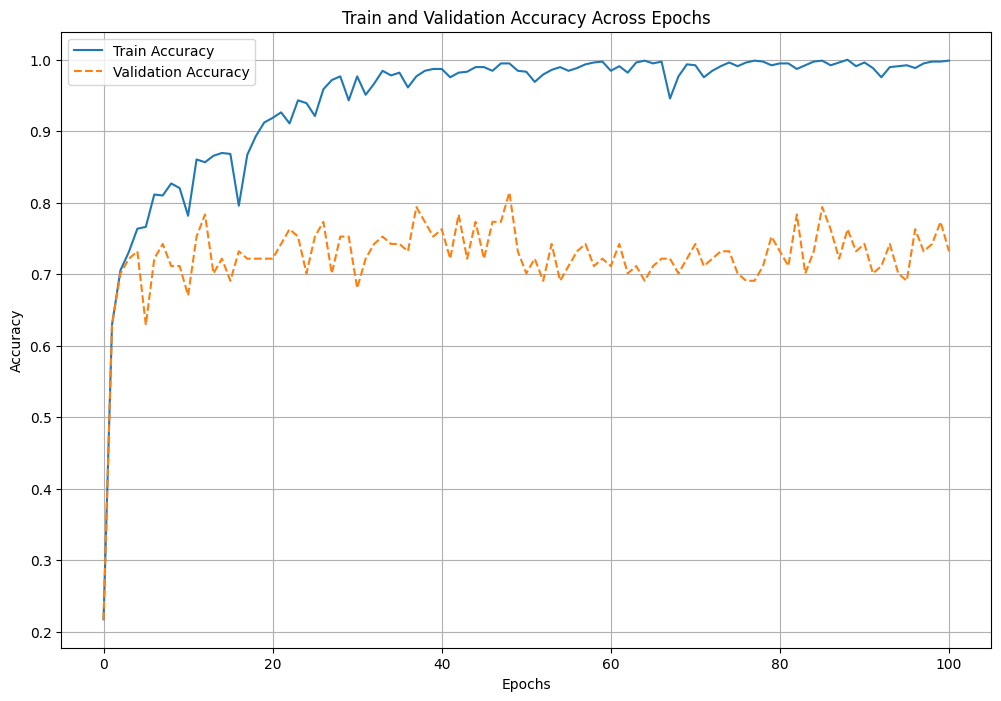

In [ ]:
plot_acc_per_epoch(acc_per_epoch)

### Bigger Model with Batch Normalization and Adam Optimizer with L2 Regularization

In [ ]:
bigger_model_4 = nn.Sequential(
    nn.Linear(PCA_NUM_COMPONENTS, 100),
    nn.BatchNorm1d(100),
    nn.SiLU(),
    nn.Linear(100, 150),
    nn.BatchNorm1d(150),
    nn.SiLU(),
    nn.Linear(150, 200),
    nn.BatchNorm1d(200),
    nn.SiLU(),
    nn.Linear(200, 200),
    nn.BatchNorm1d(200),
    nn.SiLU(),
    nn.Linear(200, 150),
    nn.BatchNorm1d(150),
    nn.SiLU(),
    nn.Linear(150, 100),
    nn.BatchNorm1d(100),
    nn.SiLU(),
    nn.Linear(100, NUM_CLASSES)
)

In [ ]:
bigger_opt_4 = optim.Adam(bigger_model_4.parameters(), LR, weight_decay=0.001)

In [ ]:
acc_per_epoch = train_model(bigger_model_4, bigger_opt_4, 100)

Begin training model
Epoch 10/100
Epoch 20/100
Epoch 30/100
Epoch 40/100
Epoch 50/100
Epoch 60/100
Epoch 70/100
Epoch 80/100
Epoch 90/100
Epoch 100/100
End training model


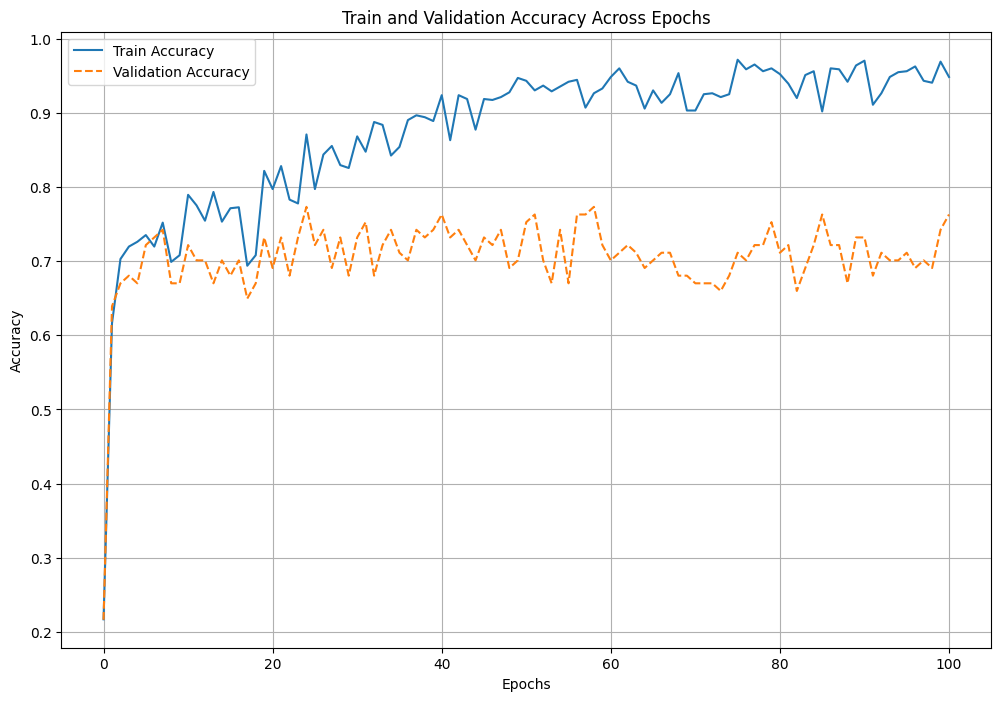

In [ ]:
plot_acc_per_epoch(acc_per_epoch)

### Results on Held-out Test Set

In [ ]:
results = []
for name, model in [
    ('Baseline', baseline_model),
    ('Bigger', bigger_model),
    ('Bigger with L2', bigger_model_2),
    ('Bigger with Adam', bigger_model_3),
    ('Bigger with Adam and L2', bigger_model_4)
]:
    accuracy = eval_model(model, test_loader)
    results.append({'Model': name, 'Test Accuracy': accuracy})

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='Test Accuracy', ascending=False)
print('Test set acc:')
print(results_df)

Test set acc:
                     Model  Test Accuracy
4  Bigger with Adam and L2       0.762887
3         Bigger with Adam       0.731959
0                 Baseline       0.711340
1                   Bigger       0.649485
2           Bigger with L2       0.639175


### Final Metrics on Best Model

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [ ]:
pred_logits = bigger_model_4(test_features_tensor)
pred_targets = torch.argmax(pred_logits, 1).numpy()

In [ ]:
print(classification_report(test_targets, pred_targets, target_names=AGE_GROUP_CATEGORIES))

              precision    recall  f1-score   support

      Kitten       0.94      0.68      0.79        25
       Adult       0.77      0.84      0.80        51
      Senior       0.61      0.67      0.64        21

    accuracy                           0.76        97
   macro avg       0.77      0.73      0.74        97
weighted avg       0.78      0.76      0.76        97



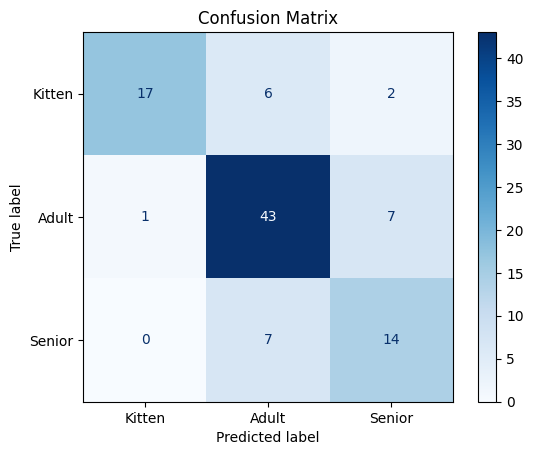

In [ ]:
cm = confusion_matrix(test_targets, pred_targets)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=AGE_GROUP_CATEGORIES)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

These results align with intuition. It is not unexpected that the model's main misclassifications would be predicting Adult on non-adults, as this is the majority class and is also the middle age group. Older kittens and young adults may sound similar to each other, and seniors and older adults may also sound similar to each other. 'Adult' is also the majority class, with ~double the samples of each of the other two age groups. There were few cases of mispredicting a kitten as a senior and vice versa because these are the most different in age.

A macro F1-score of 0.74 on the test set is reasonable for a relatively shallow network with only dense layers. It strikes a balance between minimal false positives and false negatives on all age groups, not just the majority (Adult). The results could likely be improved with a deeper network or a different architecture like CNN.